In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1) Charger ton dataset final
df = pd.read_csv("Car-Data-Occasion-Clean-5.csv")

y = df["Prix"]
X = df.drop(columns=["Prix"])

# 2) Colonnes numériques / catégorielles (adapte si besoin)
num_cols = ["Annee", "Kilometrage", "Puissance Fiscale"]
cat_cols = [c for c in X.columns if c not in num_cols]

# 3) Préprocesseur
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

# 4) Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [59]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "KNN": KNeighborsRegressor(n_neighbors=10, weights="distance"),
}


results = []

for name, reg in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess),
                           ("regressor", reg)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Modele": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
print(results_df)


             Modele           MAE          RMSE        R2
0  LinearRegression  18927.495874  35917.611867  0.670625
1             Ridge  18796.367966  34324.919636  0.699188
2      DecisionTree  19164.149307  34502.753903  0.696063
3      RandomForest  15542.384690  30658.555010  0.760018
4               KNN  16144.895286  30703.521501  0.759313


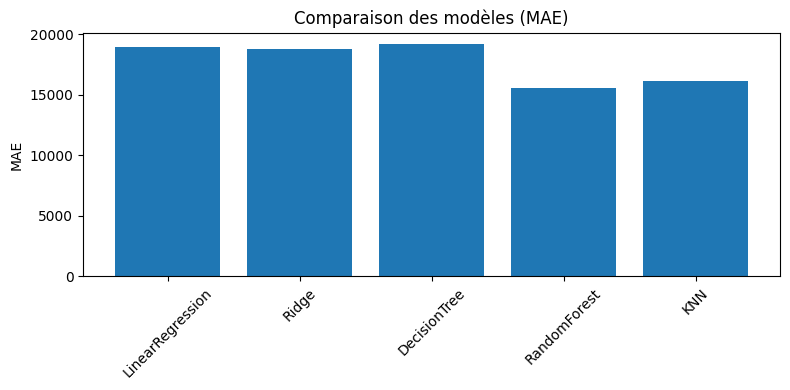

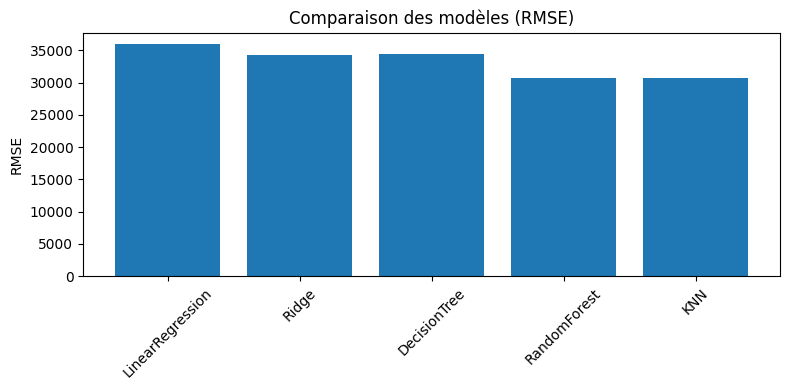

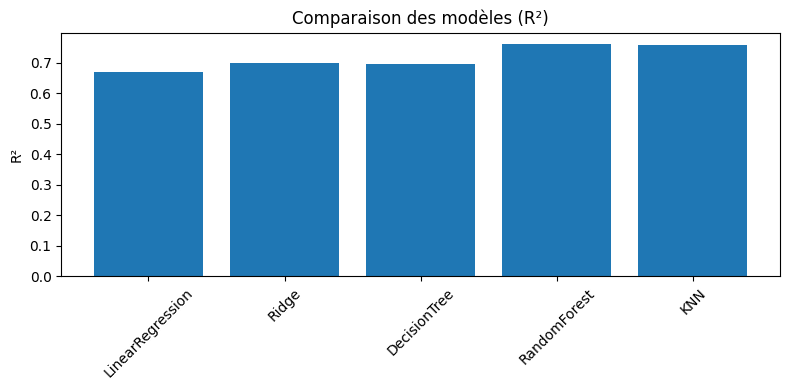

In [60]:
import matplotlib.pyplot as plt

# Assure-toi que results_df est trié comme tu veux
models_names = results_df["Modele"]

plt.figure(figsize=(8,4))
plt.bar(models_names, results_df["MAE"])
plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.title("Comparaison des modèles (MAE)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(models_names, results_df["RMSE"])
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Comparaison des modèles (RMSE)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(models_names, results_df["R2"])
plt.xticks(rotation=45)
plt.ylabel("R²")
plt.title("Comparaison des modèles (R²)")
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

df = pd.read_csv("Car-Data-Occasion-Clean-5.csv")

y = df["Prix"]
X = df.drop(columns=["Prix"])

num_cols = ["Annee", "Kilometrage", "Puissance Fiscale"]
cat_cols = [c for c in X.columns if c not in num_cols]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", KNeighborsRegressor(
            n_neighbors=10,
            weights="distance"
        )),
    ]
)

knn_pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Annee', 'Kilometrage',
                                                   'Puissance Fiscale']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Marque', 'Modele',
                                                   'Carburant', 'Boite Vitesse',
                                                   'Etat Generale'])])),
                ('regressor',
                 KNeighborsRegressor(n_neighbors=10, weights='distance'))])

In [19]:
nouvelle_voiture = pd.DataFrame([{
    "Marque": "Volkswagen",
    "Modele": "Golf 7",
    "Annee": 2015,
    "Kilometrage": 173000,
    "Carburant": "Essence",
    "Boite Vitesse": "Manuelle",
    "Puissance Fiscale": 5,
    "Etat Generale": "occasion"
}])

prix_pred = knn_pipe.predict(nouvelle_voiture)[0]
print(f"Prix prédit: {prix_pred:.0f}")


Prix prédit: 57601
